# AcousticBrainz EDA

[AcousticBrainz](https://acousticbrainz.org) holds audio descriptors for MusicBrainz recordings. Volunteers ran the Essentia extractor on their own audio files from 2015 to 2022. Nothing in it was entered by hand:
- **low-level**: signal measurements (loudness, spectrum, MFCC, tempo, key, chords...).
- **high-level**: classifier outputs computed from the low-level data (`mood_sad`, `genre_rosamerica`, `danceability`...). The classifiers were trained on small hand-labelled datasets.

This notebook uses the **same 1,000-song random sample** as the lyrics section of the main EDA (`DAP_IEDA_Template.ipynb`, `random_state=42`). It fetches **every field** for the sampled songs that have an AcousticBrainz entry, then looks at coverage (including against lyrics), what the fields contain, and whether the mood fields agree with MuSe.

Runs top to bottom from `proposal/`. Needs `pandas`, `numpy`, `matplotlib` and `pyarrow`. The first run downloads ~30 MB from the API and takes a few minutes. Later runs read the cache.

## Setup

In [1]:
import ast
import gzip
import json
import threading
import time
import urllib.request
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.error import HTTPError, URLError

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../data/raw")
INTERIM = Path("../data/interim")
AB_DIR = DATA / "acousticbrainz"
AB_DIR.mkdir(parents=True, exist_ok=True)

muse = pd.read_csv(DATA / "muse" / "muse_v3.csv")
muse["seeds"] = muse["seeds"].map(ast.literal_eval)
sample = muse.sample(1000, random_state=42).copy()  # same sample as the main EDA's lyrics section
print(f"{len(sample):,} sampled MuSe songs, {sample['mbid'].notna().sum():,} with an mbid")

1,000 sampled MuSe songs, 678 with an mbid


## Fetching from the API

The [full dumps](https://data.metabrainz.org/pub/musicbrainz/acousticbrainz/dumps/) cover every recording, in many 1–2 GB `.tar.zst` parts. The [API](https://acousticbrainz.readthedocs.io/api.html) is still up, so we fetch only the sampled recordings, 25 MBIDs per call:

1. `count`: submissions per MBID, for coverage.
2. `high-level` and `low-level`: the full documents, for MBIDs with at least 1 submission. One recording can have several submissions (different users' files). We keep **submission 0**.

Limits: 100 requests per 10 s. The server is slow (~25 s per `high-level` call of 25 MBIDs), so we run 24 threads and space call starts 0.11 s apart. Raw documents are cached as gzipped JSON lines in `data/raw/acousticbrainz/`. A rerun only fetches what's missing.

In [2]:
AB_API = "https://acousticbrainz.org/api/v1"
BATCH = 25
THREADS = 24
_slot = threading.Lock()
_next_time = [0.0]


def ab_get(endpoint, mbids):
    """One API call for up to 25 MBIDs, at most ~9 call starts per second, with retries."""
    url = f"{AB_API}/{endpoint}?recording_ids={';'.join(mbids)}"
    for attempt in range(6):
        with _slot:
            wait = _next_time[0] - time.time()
            _next_time[0] = max(_next_time[0], time.time()) + 0.11
        if wait > 0:
            time.sleep(wait)
        try:
            with urllib.request.urlopen(url, timeout=300) as r:
                return json.load(r)
        except HTTPError as e:
            if e.code == 429:
                time.sleep(int(e.headers.get("X-RateLimit-Reset-In", 10)) + 1)
            elif e.code < 500:
                raise
            else:
                time.sleep(2 ** attempt)
        except (URLError, TimeoutError, ConnectionError):
            time.sleep(2 ** attempt)
    raise RuntimeError(f"gave up on {endpoint} batch starting {mbids[0]}")


def read_cache(path):
    """Records from a (gzipped) jsonl cache. Stops cleanly at a line cut off by an interrupted run."""
    if not path.exists():
        return []
    opener = gzip.open if path.suffix == ".gz" else open
    recs = []
    try:
        with opener(path, "rt", encoding="utf-8") as f:
            for line in f:
                recs.append(json.loads(line))
    except (EOFError, json.JSONDecodeError, gzip.BadGzipFile):
        pass
    return recs


def ab_fetch(endpoint, mbids, cache, parse):
    """Fetch MBIDs missing from the cache. parse(body, batch) returns one record (dict with "mbid") per MBID."""
    cached = read_cache(cache)
    opener = gzip.open if cache.suffix == ".gz" else open
    if cached:  # rewrite without any cut-off tail, so records appended below stay readable
        with opener(cache, "wt", encoding="utf-8") as f:
            f.writelines(json.dumps(r) + "\n" for r in cached)
    done = {r["mbid"] for r in cached}
    todo = [m for m in mbids if m not in done]
    batches = [todo[i:i + BATCH] for i in range(0, len(todo), BATCH)]
    print(f"{endpoint}: {len(done):,} cached, {len(todo):,} to fetch in {len(batches):,} calls")
    if not batches:
        return
    start = time.time()
    with opener(cache, "at", encoding="utf-8") as f, ThreadPoolExecutor(THREADS) as ex:
        for i, (batch, body) in enumerate(zip(batches, ex.map(lambda b: ab_get(endpoint, b), batches)), 1):
            for rec in parse(body, batch):
                f.write(json.dumps(rec) + "\n")
            if i % 100 == 0:
                f.flush()
                print(f"  {i:,}/{len(batches):,} calls, {(time.time() - start) / 60:.0f} min")


def parse_count(body, batch):
    return [{"mbid": m, "count": body.get(m, {}).get("count", 0)} for m in batch]


def parse_doc(body, batch):
    """Keep submission 0's full document."""
    return [{"mbid": m, "doc": body.get(m, {}).get("0")} for m in batch]

In [3]:
sample_mbids = sample["mbid"].dropna().unique().tolist()
ab_fetch("count", sample_mbids, AB_DIR / "count.jsonl", parse_count)
ab_count = pd.DataFrame(read_cache(AB_DIR / "count.jsonl")).drop_duplicates("mbid", keep="last").set_index("mbid")["count"]
covered = ab_count[ab_count > 0].index.tolist()
covered = [m for m in sample_mbids if ab_count.get(m, 0) > 0]
print(f"{len(covered):,} sampled recordings have >=1 AcousticBrainz submission")

count: 61,217 cached, 0 to fetch in 0 calls


573 sampled recordings have >=1 AcousticBrainz submission


In [4]:
ab_fetch("high-level", covered, AB_DIR / "highlevel.jsonl.gz", parse_doc)
ab_fetch("low-level", covered, AB_DIR / "lowlevel.jsonl.gz", parse_doc)

high-level: 0 cached, 573 to fetch in 23 calls


low-level: 573 cached, 0 to fetch in 0 calls


## Coverage

### Submissions per recording

Of the songs with an `mbid`, how many have an entry, and how many submissions each.

In [5]:
sample["ab_count"] = sample["mbid"].map(ab_count).fillna(0).astype(int)
sample["has_ab"] = sample["ab_count"] > 0

print(f"With an mbid:          {sample['mbid'].notna().sum():,} ({sample['mbid'].notna().mean():.1%} of the sample)")
print(f"With AcousticBrainz:   {sample['has_ab'].sum():,} ({sample['has_ab'].mean():.1%} of the sample, "
      f"{sample['has_ab'].sum() / sample['mbid'].notna().sum():.1%} of those with an mbid)")

subs = sample.loc[sample["has_ab"], "ab_count"]
bins = pd.cut(subs, [0, 1, 2, 5, 10, 50, np.inf], labels=["1", "2", "3-5", "6-10", "11-50", ">50"])
bins.value_counts().sort_index().rename("songs").to_frame()

With an mbid:          678 (67.8% of the sample)
With AcousticBrainz:   573 (57.3% of the sample, 84.5% of those with an mbid)


,songs
ab_count,
1,99
2,65
3-5,103
6-10,88
11-50,164
>50,54


### Lyrics × AcousticBrainz (2×2)

*Has lyrics* means LRCLIB had an exact artist + title match with lyrics text (status `lyrics` in the main EDA).

In [6]:
LRCLIB_CACHE = DATA / "lrclib" / "sample_1000.jsonl"
records = {r["lastfm_url"]: r for r in read_cache(LRCLIB_CACHE)}


def has_lyrics(r):
    """Same rule as status == "lyrics" in the main EDA."""
    if r is None or "error" in r or not r["candidates"] or r["match_id"] is None:
        return False
    matched = next(c for c in r["candidates"] if c["id"] == r["match_id"])
    return not matched["instrumental"] and bool((r["plain_lyrics"] or "").strip())


sample["has_lyrics"] = sample["lastfm_url"].map(lambda u: has_lyrics(records.get(u)))

table = pd.crosstab(sample["has_lyrics"].map({True: "lyrics", False: "no lyrics"}).rename("Lyrics"),
                    sample["has_ab"].map({True: "AcousticBrainz", False: "no AcousticBrainz"}).rename("AcousticBrainz"),
                    margins=True, margins_name="total")
table

AcousticBrainz,AcousticBrainz,no AcousticBrainz,total
Lyrics,,,
lyrics,424,167,591
no lyrics,149,260,409
total,573,427,1000


In [7]:
(table / len(sample)).map("{:.1%}".format)

AcousticBrainz,AcousticBrainz,no AcousticBrainz,total
Lyrics,,,
lyrics,42.4%,16.7%,59.1%
no lyrics,14.9%,26.0%,40.9%
total,57.3%,42.7%,100.0%


In [8]:
lyr_rate = sample.groupby("has_ab")["has_lyrics"].mean()
print(f"Lyrics rate: {lyr_rate[True]:.1%} with AcousticBrainz, {lyr_rate[False]:.1%} without")
both = (sample["has_lyrics"] & sample["has_ab"]).mean()
print(f"Both: {both:.1%} of the sample, about {both * len(muse):,.0f} songs if the rate holds for all of MuSe")
either = (sample["has_lyrics"] | sample["has_ab"]).mean()
print(f"Either: {either:.1%} of the sample, about {either * len(muse):,.0f} songs if the rate holds for all of MuSe")

Lyrics rate: 74.0% with AcousticBrainz, 39.1% without
Both: 42.4% of the sample, about 38,160 songs if the rate holds for all of MuSe
Either: 74.0% of the sample, about 66,601 songs if the rate holds for all of MuSe


## Building the tables

**High-level** (one row per recording): for each of the 18 classifiers, `{classifier}.value` (top class) and `{classifier}.{class}` (probability of each class). The API's `probability` field is just the top class's probability, so it's left out. Also `audio.*` (properties of the analysed file) and a few file tags.

**Low-level** (one row per recording):
- scalars kept as is (`rhythm.bpm`, `tonal.key_scale`...);
- frame statistics of scalar descriptors kept in full (`lowlevel.spectral_centroid.mean`, `.median`, `.var`, `.min`, `.max`, `.dmean`...);
- for vector descriptors (MFCC, HPCP, mel/bark/ERB bands...) only the per-coefficient `mean` is kept;
- dropped: MFCC/GFCC covariance matrices and `rhythm.beats_position` (a variable-length list of beat times; `rhythm.beats_count` is kept).

Saved to `data/interim/acousticbrainz_highlevel.parquet` and `acousticbrainz_lowlevel.parquet`.

In [9]:
def first(tag):
    return tag[0] if isinstance(tag, list) and tag else tag


def flat_high(doc):
    row = {}
    for clf, v in doc["highlevel"].items():
        row[f"{clf}.value"] = v["value"]
        row.update({f"{clf}.{cls}": p for cls, p in v["all"].items()})
    meta = doc.get("metadata", {})
    row.update({f"audio.{k}": v for k, v in meta.get("audio_properties", {}).items() if k != "md5_encoded"})
    tags = meta.get("tags", {})
    for t in ["date", "originaldate", "genre", "releasecountry", "media"]:
        row[f"tags.{t}"] = first(tags.get(t))
    row["tags.n"] = len(tags)
    return row


def flat_low(doc):
    row = {}
    for group in ["lowlevel", "rhythm", "tonal"]:
        for k, v in doc.get(group, {}).items():
            name = f"{group}.{k}"
            if k == "beats_position":
                continue
            if isinstance(v, (int, float, str)):
                row[name] = v
            elif isinstance(v, list):
                row.update({f"{name}.{i}": x for i, x in enumerate(v)})
            elif isinstance(v, dict):
                for stat, x in v.items():
                    if isinstance(x, (int, float)):
                        row[f"{name}.{stat}"] = x
                    elif stat == "mean":
                        row.update({f"{name}.mean.{i}": y for i, y in enumerate(x)})
    return row


def build(cache, flat):
    keep = set(covered)  # the cache may also hold recordings from an earlier, larger run
    rows, missing = [], 0
    for r in read_cache(cache):
        if r["mbid"] not in keep:
            continue
        if r["doc"]:
            rows.append({"mbid": r["mbid"], **flat(r["doc"])})
        else:
            missing += 1
    df = pd.DataFrame(rows).drop_duplicates("mbid", keep="last").set_index("mbid")
    print(f"{cache.name}: {len(df):,} recordings x {df.shape[1]:,} columns ({missing} without a document)")
    return df


high = build(AB_DIR / "highlevel.jsonl.gz", flat_high)
low = build(AB_DIR / "lowlevel.jsonl.gz", flat_low)
high.to_parquet(INTERIM / "acousticbrainz_highlevel.parquet")
low.to_parquet(INTERIM / "acousticbrainz_lowlevel.parquet")

highlevel.jsonl.gz: 570 recordings x 104 columns (3 without a document)


lowlevel.jsonl.gz: 573 recordings x 1,126 columns (0 without a document)


## High-level fields

### What each classifier says

One row per classifier: its classes, the most common top class, and how sure it usually is (median top-class probability). A median near 0.5 for a two-class classifier means it rarely commits.

In [10]:
CLASSIFIERS = sorted({c.split(".")[0] for c in high.columns if c.endswith(".value")})
summary = []
for clf in CLASSIFIERS:
    probs = high[[c for c in high.columns if c.startswith(clf + ".") and c != f"{clf}.value"]]
    top = high[f"{clf}.value"].value_counts(normalize=True)
    summary.append({
        "classifier": clf,
        "classes": probs.shape[1],
        "most common top class": f"{top.index[0]} ({top.iloc[0]:.0%})",
        "median top prob": round(probs.max(axis=1).median(), 2),
        "missing": high[f"{clf}.value"].isna().sum(),
    })
pd.DataFrame(summary).set_index("classifier")

,classes,most common top class,median top prob,missing
classifier,,,,
danceability,2,not_danceable (60%),0.95,0
gender,2,female (61%),0.77,0
genre_dortmund,9,electronic (89%),0.98,0
genre_electronic,5,ambient (64%),0.63,0
genre_rosamerica,8,roc (24%),0.58,0
genre_tzanetakis,10,jaz (92%),0.31,0
ismir04_rhythm,10,VienneseWaltz (33%),0.55,0
mood_acoustic,2,not_acoustic (68%),0.90,0
mood_aggressive,2,not_aggressive (84%),0.97,0


### Mood classifiers

Distribution of the 7 binary mood probabilities. Values piled up at 0 or 1 mean the classifier is overconfident; a spread means it's usable as a graded score.

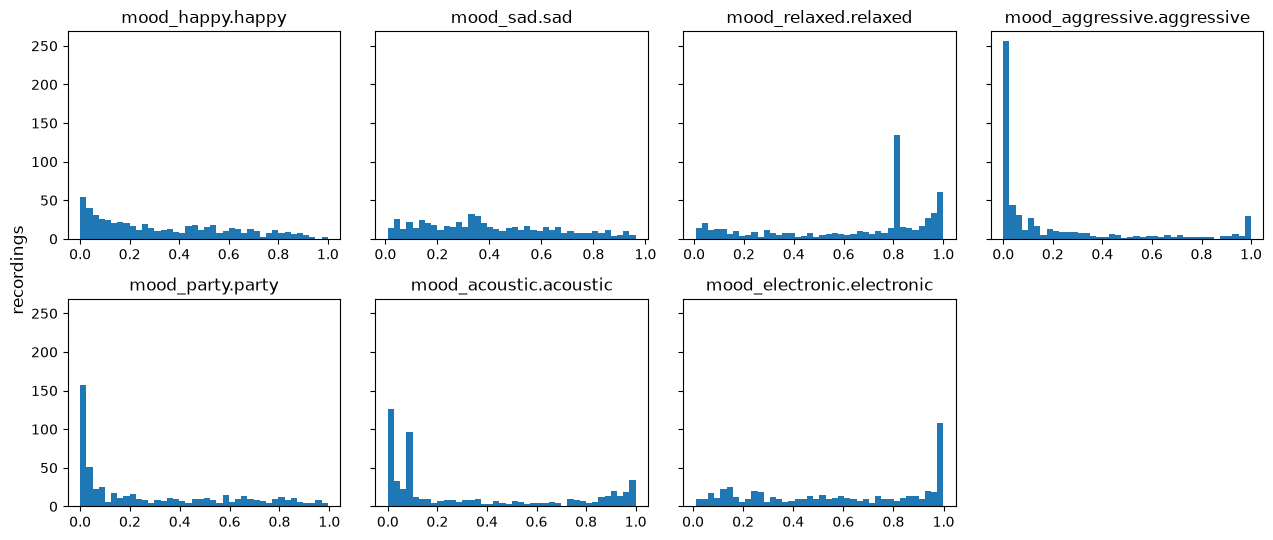

,count,mean,std,min,25%,50%,75%,max
mood_happy.happy,570.0,0.34,0.27,0.00,0.09,0.27,0.55,1.00
mood_sad.sad,570.0,0.40,0.25,0.01,0.19,0.35,0.59,0.96
mood_relaxed.relaxed,570.0,0.65,0.32,0.01,0.39,0.81,0.88,1.00
mood_aggressive.aggressive,570.0,0.20,0.30,0.00,0.00,0.04,0.25,1.00
mood_party.party,570.0,0.29,0.31,0.00,0.01,0.17,0.56,0.99
mood_acoustic.acoustic,570.0,0.34,0.36,0.00,0.04,0.12,0.73,1.00
mood_electronic.electronic,570.0,0.58,0.33,0.01,0.26,0.59,0.93,1.00


In [11]:
MOODS = ["mood_happy", "mood_sad", "mood_relaxed", "mood_aggressive", "mood_party", "mood_acoustic", "mood_electronic"]
mood_cols = [f"{m}.{m.split('_')[1]}" for m in MOODS]  # e.g. mood_sad.sad

fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharey=True)
for ax, col in zip(axes.flat, mood_cols):
    ax.hist(high[col].dropna(), bins=40)
    ax.set_title(col)
axes.flat[-1].axis("off")
fig.supylabel("recordings")
plt.tight_layout()
plt.show()

high[mood_cols].describe().T.round(2)

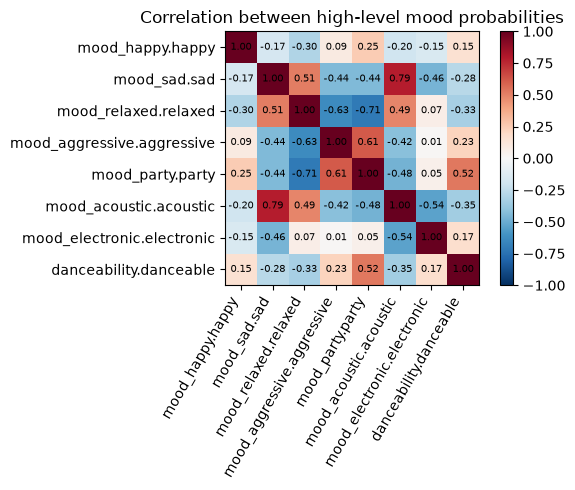

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5))
corr = high[mood_cols + ["danceability.danceable"]].corr()
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
ax.set_title("Correlation between high-level mood probabilities")
plt.tight_layout()
plt.show()

### Do the mood fields agree with MuSe?

Two checks against MuSe's own (tag-based) labels:
1. Spearman correlation with MuSe's `valence_tags` and `arousal_tags`. Expect `mood_happy` up with valence, `mood_sad` down; `mood_aggressive` and `mood_party` up with arousal, `mood_relaxed` down.
2. Mean probability for songs whose only seed is a matching mood word (small groups in a 1,000-song sample, so read the `songs` column).

MuSe's valence/arousal come from the words people tagged, and AcousticBrainz from the sound, so this tests whether the sound-based scores carry the same mood signal.

In [13]:
m = sample[sample["has_ab"]].join(high, on="mbid")
cols = mood_cols + ["danceability.danceable"]
ranks = m[cols].rank()  # Spearman = Pearson on ranks (avoids a scipy dependency)
spear = pd.DataFrame({
    "valence_tags": ranks.corrwith(m["valence_tags"].rank()),
    "arousal_tags": ranks.corrwith(m["arousal_tags"].rank()),
}).round(3)
spear

,valence_tags,arousal_tags
mood_happy.happy,0.096,0.097
mood_sad.sad,0.066,-0.263
mood_relaxed.relaxed,-0.022,-0.256
mood_aggressive.aggressive,-0.062,0.126
mood_party.party,-0.001,0.136
mood_acoustic.acoustic,0.064,-0.250
mood_electronic.electronic,-0.107,0.070
danceability.danceable,0.065,0.162


In [14]:
single = m[m["seeds"].map(len) == 1].assign(seed=lambda d: d["seeds"].str[0])
SEEDS = ["happy", "sad", "relaxed", "calm", "aggressive", "angry", "party", "energetic", "mellow", "melancholy"]
seed_table = single[single["seed"].isin(SEEDS)].groupby("seed")[mood_cols].mean()
seed_table.insert(0, "songs", single["seed"].value_counts())
seed_table.loc[[s for s in SEEDS if s in seed_table.index]].round(2)

,songs,mood_happy.happy,mood_sad.sad,mood_relaxed.relaxed,mood_aggressive.aggressive,mood_party.party,mood_acoustic.acoustic,mood_electronic.electronic
seed,,,,,,,,
happy,11,0.54,0.38,0.53,0.12,0.44,0.23,0.47
sad,5,0.28,0.68,0.85,0.04,0.22,0.58,0.32
relaxed,2,0.09,0.35,0.82,0.00,0.02,0.48,0.52
calm,1,0.16,0.17,0.81,0.00,0.00,0.10,0.98
aggressive,6,0.18,0.13,0.56,0.40,0.22,0.06,0.83
angry,4,0.43,0.06,0.44,0.41,0.37,0.06,0.70
energetic,5,0.36,0.15,0.51,0.38,0.27,0.05,0.65
mellow,3,0.50,0.50,0.79,0.02,0.03,0.61,0.57
melancholy,4,0.24,0.70,0.81,0.06,0.08,0.80,0.41


## Low-level fields

The low-level table is mostly signal statistics. Below: an overview of its columns, then the fields with an obvious mood reading (key scale, tempo, loudness).

In [15]:
groups = pd.Series(low.columns).str.split(".").str[:2].str.join(".")
overview = groups.value_counts().rename("columns").to_frame()
print(f"{low.shape[1]:,} low-level columns from {len(overview)} descriptors")
overview.head(20)

1,126 low-level columns from 82 descriptors


,columns
rhythm.bpm_histogram,250
lowlevel.melbands128,128
lowlevel.erbbands,40
lowlevel.melbands,40
tonal.hpcp,36
tonal.thpcp,36
lowlevel.barkbands,27
tonal.chords_histogram,24
lowlevel.gfcc,13
lowlevel.mfcc,13


In [16]:
missing = low.isna().mean()
print(f"Columns with any missing value: {(missing > 0).sum()} of {len(missing)}")
missing[missing > 0].sort_values(ascending=False).head(10).map("{:.1%}".format)

Columns with any missing value: 496 of 1126


rhythm.bpm_histogram_second_peak_spread    99.8%
rhythm.bpm_histogram_second_peak_bpm       99.8%
rhythm.bpm_histogram_first_peak_weight     99.8%
rhythm.bpm_histogram_first_peak_bpm        99.8%
rhythm.bpm_histogram.249                   99.8%
rhythm.bpm_histogram.248                   99.8%
rhythm.bpm_histogram.247                   99.8%
rhythm.bpm_histogram.246                   99.8%
rhythm.bpm_histogram.245                   99.8%
rhythm.bpm_histogram.244                   99.8%
dtype: str

In [17]:
lm = sample[sample["has_ab"]].join(low[["tonal.key_scale", "tonal.chords_scale", "rhythm.bpm", "lowlevel.average_loudness"]], on="mbid")
lm["quadrant"] = np.select(
    [(lm["valence_tags"] >= 5) & (lm["arousal_tags"] >= 5), (lm["valence_tags"] >= 5), (lm["arousal_tags"] >= 5)],
    ["pos valence / high arousal", "pos valence / low arousal", "neg valence / high arousal"],
    "neg valence / low arousal",
)
out = lm.groupby("quadrant").agg(
    songs=("mbid", "size"),
    minor_key=("tonal.key_scale", lambda s: (s == "minor").mean()),
    median_bpm=("rhythm.bpm", "median"),
    median_loudness=("lowlevel.average_loudness", "median"),
)
out["minor_key"] = out["minor_key"].map("{:.1%}".format)
out.round(2)

,songs,minor_key,median_bpm,median_loudness
quadrant,,,,
neg valence / high arousal,34,61.8%,118.69,0.92
neg valence / low arousal,164,44.5%,123.12,0.83
pos valence / high arousal,129,40.3%,120.01,0.90
pos valence / low arousal,246,36.2%,120.24,0.81


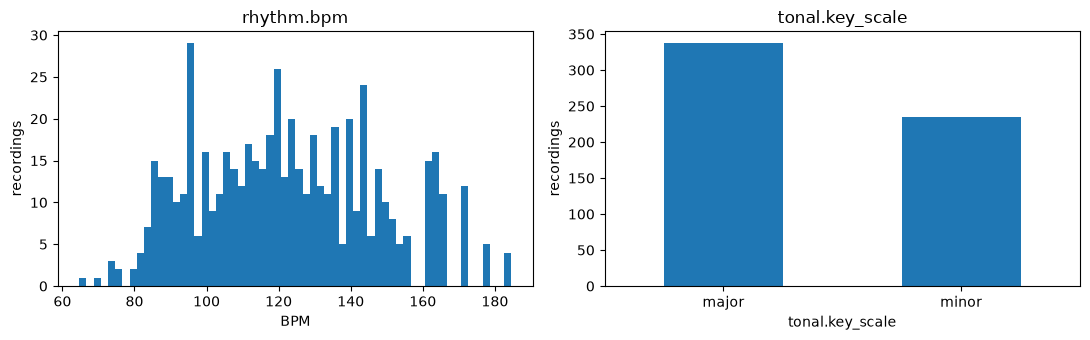

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(low["rhythm.bpm"].dropna(), bins=60)
axes[0].set_title("rhythm.bpm")
axes[0].set_xlabel("BPM")
low["tonal.key_scale"].value_counts().plot.bar(ax=axes[1], rot=0)
axes[1].set_title("tonal.key_scale")
for ax in axes:
    ax.set_ylabel("recordings")
plt.tight_layout()
plt.show()

## Analysed files

Properties of the audio file each volunteer analysed (submission 0). Lossy files and odd lengths (a 30 s preview, a full-album rip) can distort the descriptors.

In [19]:
print(high["audio.codec"].value_counts(normalize=True).head(6).map("{:.1%}".format).to_string())
print(f"\nlossless: {high['audio.lossless'].astype(bool).mean():.1%}")
length = high["audio.length"] / 60
print(f"length (min): median {length.median():.1f}, <1 min {(length < 1).mean():.1%}, >15 min {(length > 15).mean():.1%}")

audio.codec
mp3          61.8%
flac         28.2%
aac           7.2%
vorbis        1.8%
alac          0.9%
pcm_s16le     0.2%

lossless: 29.3%
length (min): median 4.1, <1 min 0.4%, >15 min 1.1%
